## 1. Sentiment140 Confusion Matrix Comparison

This section compares the confusion matrices of the three Sentiment140 models under two settings.

First, the standard binary confusion matrix is reported using the original binary predictions.
Second, a neutral-aware confusion matrix is constructed by comparing the original binary gold labels against the post-hoc three-way predictions. Since Sentiment140 does not provide a gold neutral label, the neutral-aware matrix is reported as a 2×3 confusion matrix rather than a standard 3×3 matrix.

This comparison helps show how the neutral band absorbs uncertain cases while preserving the original binary supervision setting.

ROOT_DIR: /Users/victor/Desktop/Graduation_Thesis/Code
PRED_DIR: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/predictions
FIG_DIR: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/figures

Available prediction CSV files:
 - pred_test_bert_binary.csv
 - pred_test_bert_neutral_0.40_0.60.csv
 - pred_test_lstm_binary.csv
 - pred_test_lstm_neutral_0.40_0.60.csv
 - pred_test_tfidf_lr_binary.csv
 - pred_test_tfidf_lr_neutral_0.40_0.60.csv

tfidf lr
Reading: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/predictions/pred_test_tfidf_lr_neutral_0.40_0.60.csv
Neutral-aware 2×3 confusion matrix:


,Negative,Neutral,Positive
Negative,177993,32342,29665
Positive,28459,29323,182218


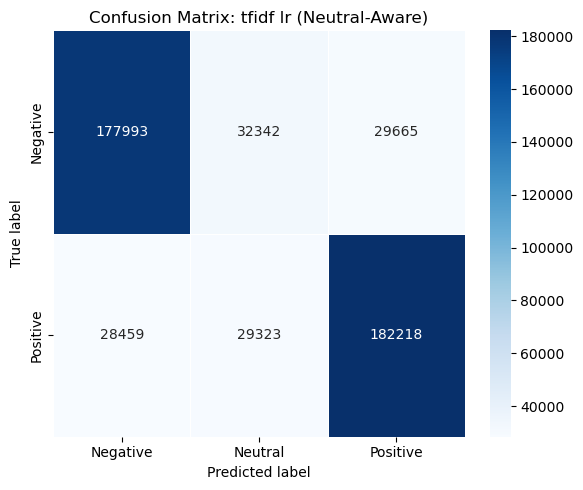

Saved figure to: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/figures/tfidf_lr_neutral_aware_confusion_matrix.png

lstm
Reading: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/predictions/pred_test_lstm_neutral_0.40_0.60.csv
Neutral-aware 2×3 confusion matrix:


,Negative,Neutral,Positive
Negative,188373,21246,30381
Positive,30146,20200,189654


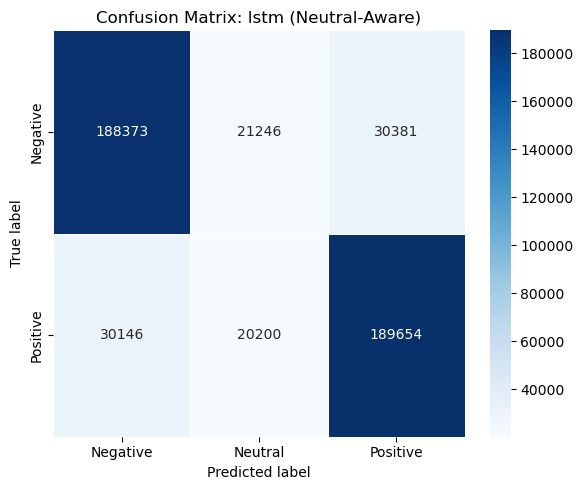

Saved figure to: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/figures/lstm_neutral_aware_confusion_matrix.png

bert
Reading: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/predictions/pred_test_bert_neutral_0.40_0.60.csv
Neutral-aware 2×3 confusion matrix:


,Negative,Neutral,Positive
Negative,206443,8228,25329
Positive,27228,8530,204242


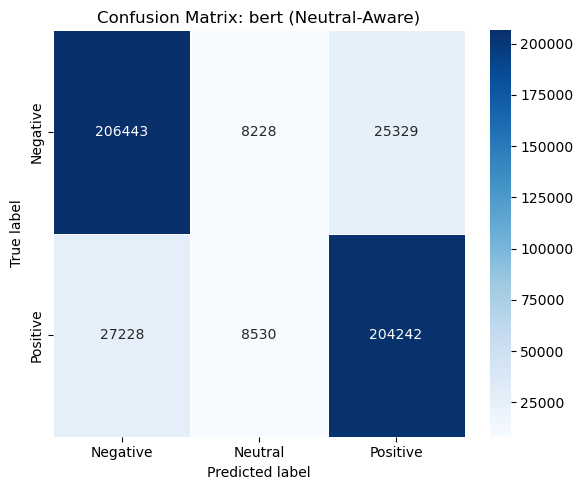

Saved figure to: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/figures/bert_neutral_aware_confusion_matrix.png


In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Path initialization
# =========================
ROOT_DIR = Path.cwd().resolve()

if ROOT_DIR.name != "Code":
    for parent in [ROOT_DIR] + list(ROOT_DIR.parents):
        if parent.name == "Code":
            ROOT_DIR = parent
            break

if ROOT_DIR.name != "Code":
    raise ValueError(
        f"Could not locate the 'Code' directory from current working directory: {Path.cwd().resolve()}"
    )

ARTIFACT_DIR = ROOT_DIR / "artifacts"
S140_DIR = ARTIFACT_DIR / "sentiment140"
PRED_DIR = S140_DIR / "predictions"
FIG_DIR = S140_DIR / "figures"

print("ROOT_DIR:", ROOT_DIR)
print("PRED_DIR:", PRED_DIR)
print("FIG_DIR:", FIG_DIR)

print("\nAvailable prediction CSV files:")
for p in sorted(PRED_DIR.glob("*.csv")):
    print(" -", p.name)

# =========================
# File mapping
# Adjust filenames here if needed
# =========================
prediction_files = {
    "tfidf lr": PRED_DIR / "pred_test_tfidf_lr_neutral_0.40_0.60.csv",
    "lstm": PRED_DIR / "pred_test_lstm_neutral_0.40_0.60.csv",
    "bert": PRED_DIR / "pred_test_bert_neutral_0.40_0.60.csv",
}

# =========================
# Label definitions
# =========================
true_label_order = [0, 1]
true_label_names = ["Negative", "Positive"]

pred_label_order = [0, 1, 2]
pred_label_names = ["Negative", "Neutral", "Positive"]

y_true_map = {
    "NEGATIVE": 0,
    "POSITIVE": 1,
    "negative": 0,
    "positive": 1,
    "0": 0,
    "1": 1,
    0: 0,
    1: 1,
}

pred_3class_map = {
    "NEGATIVE": 0,
    "NEUTRAL": 1,
    "POSITIVE": 2,
    "negative": 0,
    "neutral": 1,
    "positive": 2,
    "0": 0,
    "1": 1,
    "2": 2,
    0: 0,
    1: 1,
    2: 2,
}

# =========================
# Helper functions
# =========================
def normalize_y_true(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        normalized = series.astype(int)
    else:
        normalized = series.map(y_true_map)

    if normalized.isna().any():
        bad_values = series[normalized.isna()].drop_duplicates().tolist()
        raise ValueError(f"Some y_true values could not be mapped: {bad_values}")

    return normalized.astype(int)


def normalize_pred_3class(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        normalized = series.astype(int)
    else:
        normalized = series.map(pred_3class_map)

    if normalized.isna().any():
        bad_values = series[normalized.isna()].drop_duplicates().tolist()
        raise ValueError(f"Some pred_3class values could not be mapped: {bad_values}")

    return normalized.astype(int)


def build_2x3_confusion_matrix(y_true: pd.Series, y_pred: pd.Series) -> np.ndarray:
    cm = np.zeros((2, 3), dtype=int)
    for i, true_label in enumerate(true_label_order):
        for j, pred_label in enumerate(pred_label_order):
            cm[i, j] = int(((y_true == true_label) & (y_pred == pred_label)).sum())
    return cm


def plot_confusion_matrix_2x3(cm, title, save_path=None):
    cm_df = pd.DataFrame(
        cm,
        index=true_label_names,
        columns=pred_label_names,
    )

    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        linewidths=0.5,
        linecolor="white",
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# =========================
# Generate neutral-aware confusion matrices
# =========================
neutral_cm_results = {}

for model_title, file_path in prediction_files.items():
    print("\n" + "=" * 60)
    print(model_title)
    print("=" * 60)
    print("Reading:", file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    df = pd.read_csv(file_path)

    required_cols = {"y_true", "pred_3class"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"{file_path.name} is missing columns: {missing_cols}")

    y_true = normalize_y_true(df["y_true"])
    y_pred = normalize_pred_3class(df["pred_3class"])

    cm_2x3 = build_2x3_confusion_matrix(y_true, y_pred)
    neutral_cm_results[model_title] = cm_2x3

    print("Neutral-aware 2×3 confusion matrix:")
    display(pd.DataFrame(cm_2x3, index=true_label_names, columns=pred_label_names))

    safe_name = (
        model_title.lower()
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "_")
    )

    save_path = FIG_DIR / f"{safe_name}_neutral_aware_confusion_matrix.png"

    plot_confusion_matrix_2x3(
        cm=cm_2x3,
        title=f"Confusion Matrix: {model_title} (Neutral-Aware)",
        save_path=save_path,
    )

    print("Saved figure to:", save_path.resolve())

## 2. Sentiment140 Happiness Index Comparison

This section compares the happiness index outputs of the three Sentiment140 models:
TF-IDF + Logistic Regression, GloVe + BiLSTM, and BERT.

Two index variants are considered for each model.

- **Binary HI** is based on the original binary sentiment setting.
- **Neutral-aware HI** is based on the post-hoc three-way prediction setting, where uncertain cases are assigned to a neutral class using probability thresholds.

To improve readability, the main comparison is reported on the 0–100 scale (`hi_label_100` and `hi_prob_100`), where:
- 0 indicates the most negative extreme,
- 50 indicates the neutral midpoint,
- 100 indicates the most positive extreme.

This section focuses on cross-model comparison and the effect of introducing the neutral band.

Sentiment140 result directory: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/sentiment140/results
Sentiment140 final analysis directory: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/sentiment140
Combined Sentiment140 HI summary:


,dataset,model,index_variant,sample_size,negative_ratio,positive_ratio,mean_proba_pos,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100,neutral_ratio,neg_th,pos_th,model_display,base_model,max_len,batch_size,epochs
0,sentiment140,tfidf_lr,binary,480000,0.493590,0.506410,0.497764,0.012821,50.641042,-0.004472,49.776410,NaN,NaN,NaN,tfidf_lr,NaN,NaN,NaN,NaN
1,sentiment140,tfidf_lr,neutral_aware,480000,0.430108,0.441423,0.497764,0.011315,50.565729,-0.004472,49.776410,0.128469,0.4,0.6,tfidf_lr,NaN,NaN,NaN,NaN
2,sentiment140,glove_bilstm,binary_hi,480000,0.497354,0.502646,0.505044,0.005292,50.264583,0.010087,50.504355,0.000000,NaN,NaN,glove_bilstm,NaN,NaN,NaN,NaN
3,sentiment140,glove_bilstm,neutral_hi,480000,0.455248,0.458406,0.505044,0.003158,50.157917,0.010087,50.504355,0.086346,0.4,0.6,glove_bilstm,NaN,NaN,NaN,NaN
4,sentiment140,bert_base_uncased,binary_hi,480000,0.504694,0.495306,0.497064,-0.009388,49.530625,-0.005871,49.706437,NaN,NaN,NaN,bert,bert-base-uncased,128.0,16.0,2.0
5,sentiment140,bert_base_uncased,neutral_hi,480000,0.486815,0.478273,0.497064,-0.008542,49.572917,-0.005871,49.706437,0.034912,0.4,0.6,bert,bert-base-uncased,128.0,16.0,2.0


Cleaned and ordered Sentiment140 HI summary:


,dataset,model,index_variant,sample_size,negative_ratio,positive_ratio,mean_proba_pos,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100,neutral_ratio,neg_th,pos_th,model_display,base_model,max_len,batch_size,epochs
0,sentiment140,tfidf_lr,binary_hi,480000,0.493590,0.506410,0.497764,0.012821,50.641042,-0.004472,49.776410,NaN,NaN,NaN,tfidf_lr,NaN,NaN,NaN,NaN
1,sentiment140,lstm,binary_hi,480000,0.497354,0.502646,0.505044,0.005292,50.264583,0.010087,50.504355,0.000000,NaN,NaN,glove_bilstm,NaN,NaN,NaN,NaN
2,sentiment140,bert,binary_hi,480000,0.504694,0.495306,0.497064,-0.009388,49.530625,-0.005871,49.706437,NaN,NaN,NaN,bert,bert-base-uncased,128.0,16.0,2.0
3,sentiment140,tfidf_lr,neutral_hi,480000,0.430108,0.441423,0.497764,0.011315,50.565729,-0.004472,49.776410,0.128469,0.4,0.6,tfidf_lr,NaN,NaN,NaN,NaN
4,sentiment140,lstm,neutral_hi,480000,0.455248,0.458406,0.505044,0.003158,50.157917,0.010087,50.504355,0.086346,0.4,0.6,glove_bilstm,NaN,NaN,NaN,NaN
5,sentiment140,bert,neutral_hi,480000,0.486815,0.478273,0.497064,-0.008542,49.572917,-0.005871,49.706437,0.034912,0.4,0.6,bert,bert-base-uncased,128.0,16.0,2.0


Compact Sentiment140 HI comparison table:


,dataset,model,index_variant,sample_size,negative_ratio,neutral_ratio,positive_ratio,mean_proba_pos,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100
0,sentiment140,tfidf_lr,binary_hi,480000,0.493590,NaN,0.506410,0.497764,0.012821,50.641042,-0.004472,49.776410
1,sentiment140,lstm,binary_hi,480000,0.497354,0.000000,0.502646,0.505044,0.005292,50.264583,0.010087,50.504355
2,sentiment140,bert,binary_hi,480000,0.504694,NaN,0.495306,0.497064,-0.009388,49.530625,-0.005871,49.706437
3,sentiment140,tfidf_lr,neutral_hi,480000,0.430108,0.128469,0.441423,0.497764,0.011315,50.565729,-0.004472,49.776410
4,sentiment140,lstm,neutral_hi,480000,0.455248,0.086346,0.458406,0.505044,0.003158,50.157917,0.010087,50.504355
5,sentiment140,bert,neutral_hi,480000,0.486815,0.034912,0.478273,0.497064,-0.008542,49.572917,-0.005871,49.706437


hi_label_100 pivot:


index_variant,binary_hi,neutral_hi
model,,
tfidf_lr,50.641042,50.565729
lstm,50.264583,50.157917
bert,49.530625,49.572917


hi_prob_100 pivot:


index_variant,binary_hi,neutral_hi
model,,
tfidf_lr,49.776410,49.776410
lstm,50.504355,50.504355
bert,49.706437,49.706437


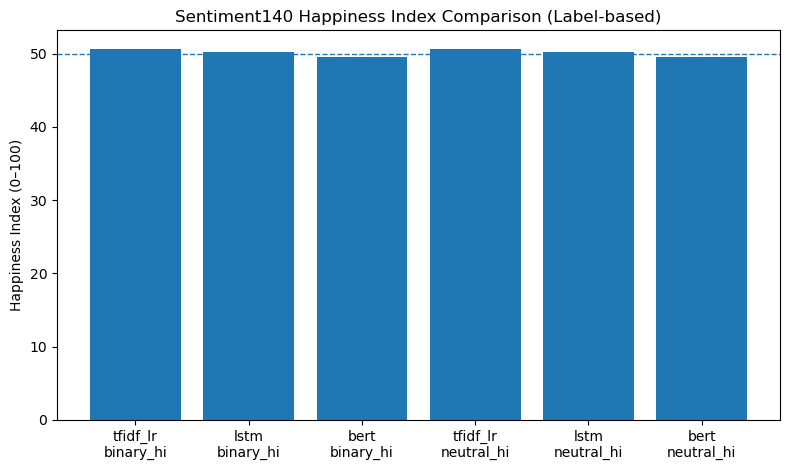

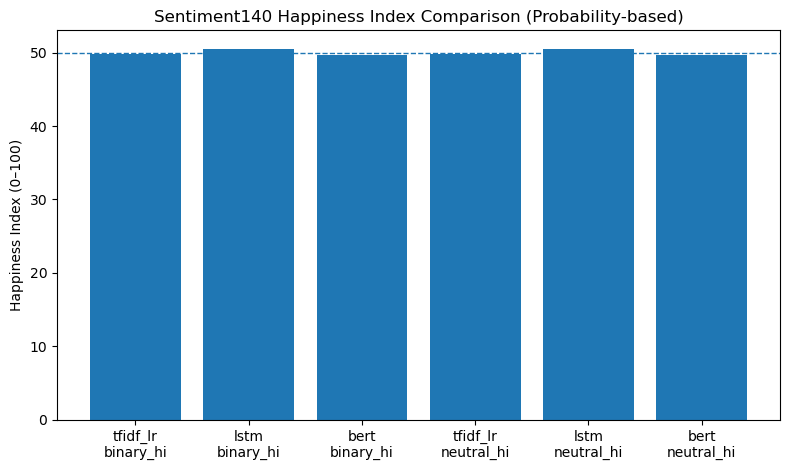

Binary vs neutral-aware change summary:


index_variant,model,delta_label_100_neutral_minus_binary,delta_prob_100_neutral_minus_binary
0,tfidf_lr,-0.075313,0.0
1,lstm,-0.106667,0.0
2,bert,0.042292,0.0


Class distribution by model and index variant:


,model,index_variant,negative_ratio,neutral_ratio,positive_ratio
0,tfidf_lr,binary_hi,0.493590,NaN,0.506410
1,lstm,binary_hi,0.497354,0.000000,0.502646
2,bert,binary_hi,0.504694,NaN,0.495306
3,tfidf_lr,neutral_hi,0.430108,0.128469,0.441423
4,lstm,neutral_hi,0.455248,0.086346,0.458406
5,bert,neutral_hi,0.486815,0.034912,0.478273


Highest label-based HI: {'model': 'tfidf_lr', 'index_variant': 'binary_hi', 'hi_label_100': 50.64104167}
Highest probability-based HI: {'model': 'lstm', 'index_variant': 'binary_hi', 'hi_prob_100': 50.50435541585835}

Saved files:
Combined summary: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/sentiment140/sentiment140_hi_summary_combined.csv
Compact comparison: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/sentiment140/sentiment140_hi_comparison_compact.csv
Label pivot: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/sentiment140/sentiment140_hi_label_pivot.csv
Probability pivot: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/sentiment140/sentiment140_hi_prob_pivot.csv
Delta summary: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/sentiment140/sentiment140_hi_delta_summary.csv
Class distribution: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/sentim

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Paths
# =========================
ROOT_DIR = Path.cwd()

# Adjust if the notebook is not directly under Code/
if ROOT_DIR.name != "Code":
    for parent in [ROOT_DIR] + list(ROOT_DIR.parents):
        if parent.name == "Code":
            ROOT_DIR = parent
            break

if ROOT_DIR.name != "Code":
    raise ValueError(
        f"Could not locate the 'Code' directory from current working directory: {Path.cwd().resolve()}"
    )

ARTIFACT_DIR = ROOT_DIR / "artifacts"
S140_DIR = ARTIFACT_DIR / "sentiment140"
S140_RESULT_DIR = S140_DIR / "results"

# Final analysis output directory
FINAL_ANALYSIS_DIR = ARTIFACT_DIR / "final_analysis"
S140_ANALYSIS_DIR = FINAL_ANALYSIS_DIR / "sentiment140"
S140_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print("Sentiment140 result directory:", S140_RESULT_DIR.resolve())
print("Sentiment140 final analysis directory:", S140_ANALYSIS_DIR.resolve())

# =========================
# Load summary files
# =========================
summary_files = {
    "tfidf_lr": S140_RESULT_DIR / "tfidf_lr_happiness_index_summary.csv",
    "glove_bilstm": S140_RESULT_DIR / "lstm_happiness_index_summary.csv",
    "bert": S140_RESULT_DIR / "bert_happiness_index_summary.csv",
}

summary_dfs = []

for model_name, file_path in summary_files.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Missing summary file: {file_path}")

    df = pd.read_csv(file_path)
    df["model_display"] = model_name
    summary_dfs.append(df)

s140_hi_df = pd.concat(summary_dfs, ignore_index=True)

print("Combined Sentiment140 HI summary:")
display(s140_hi_df)

# =========================
# Basic cleaning / ordering
# =========================
model_order = ["tfidf_lr", "lstm", "bert"]
variant_order = ["binary_hi", "neutral_hi"]

if "model" in s140_hi_df.columns:
    s140_hi_df["model"] = s140_hi_df["model"].replace({
        "tfidf_lr": "tfidf_lr",
        "glove_bilstm": "lstm",
        "bert_base_uncased": "bert",
    })
else:
    s140_hi_df["model"] = s140_hi_df["model_display"]

s140_hi_df["model"] = s140_hi_df["model"].fillna(s140_hi_df["model_display"])

s140_hi_df["index_variant"] = s140_hi_df["index_variant"].replace({
    "binary": "binary_hi",
    "binary_hi": "binary_hi",
    "neutral_aware": "neutral_hi",
    "neutral_awa": "neutral_hi",
    "neutral_hi": "neutral_hi",
})

s140_hi_df["model"] = pd.Categorical(
    s140_hi_df["model"],
    categories=model_order,
    ordered=True
)
s140_hi_df["index_variant"] = pd.Categorical(
    s140_hi_df["index_variant"],
    categories=variant_order,
    ordered=True
)

s140_hi_df = s140_hi_df.sort_values(["index_variant", "model"]).reset_index(drop=True)

print("Cleaned and ordered Sentiment140 HI summary:")
display(s140_hi_df)

# Save combined summary
combined_summary_path = S140_ANALYSIS_DIR / "sentiment140_hi_summary_combined.csv"
s140_hi_df.to_csv(combined_summary_path, index=False, encoding="utf-8")

# =========================
# Compact comparison table
# =========================
comparison_cols = [
    "dataset",
    "model",
    "index_variant",
    "sample_size",
    "negative_ratio",
    "neutral_ratio",
    "positive_ratio",
    "mean_proba_pos",
    "hi_label_raw",
    "hi_label_100",
    "hi_prob_raw",
    "hi_prob_100",
]

available_cols = [c for c in comparison_cols if c in s140_hi_df.columns]
s140_hi_compact = s140_hi_df[available_cols].copy()

print("Compact Sentiment140 HI comparison table:")
display(s140_hi_compact)

compact_path = S140_ANALYSIS_DIR / "sentiment140_hi_comparison_compact.csv"
s140_hi_compact.to_csv(compact_path, index=False, encoding="utf-8")

# =========================
# Pivot tables for easy comparison
# =========================
label_pivot = s140_hi_df.pivot(index="model", columns="index_variant", values="hi_label_100")
prob_pivot = s140_hi_df.pivot(index="model", columns="index_variant", values="hi_prob_100")

print("hi_label_100 pivot:")
display(label_pivot)

print("hi_prob_100 pivot:")
display(prob_pivot)

label_pivot_path = S140_ANALYSIS_DIR / "sentiment140_hi_label_pivot.csv"
prob_pivot_path = S140_ANALYSIS_DIR / "sentiment140_hi_prob_pivot.csv"

label_pivot.to_csv(label_pivot_path, encoding="utf-8")
prob_pivot.to_csv(prob_pivot_path, encoding="utf-8")

# =========================
# Plot 1: hi_label_100 comparison
# =========================
plot_df_label = s140_hi_df.copy()
plot_df_label["x_label"] = (
    plot_df_label["model"].astype(str)
    + "\n"
    + plot_df_label["index_variant"].astype(str)
)

plt.figure(figsize=(8, 4.8))
plt.bar(plot_df_label["x_label"], plot_df_label["hi_label_100"])
plt.axhline(50, linestyle="--", linewidth=1)
plt.ylabel("Happiness Index (0–100)")
plt.title("Sentiment140 Happiness Index Comparison (Label-based)")
plt.tight_layout()

label_fig_path = S140_ANALYSIS_DIR / "sentiment140_hi_label_comparison.png"
plt.savefig(label_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# =========================
# Plot 2: hi_prob_100 comparison
# =========================
plot_df_prob = s140_hi_df.copy()
plot_df_prob["x_label"] = (
    plot_df_prob["model"].astype(str)
    + "\n"
    + plot_df_prob["index_variant"].astype(str)
)

plt.figure(figsize=(8, 4.8))
plt.bar(plot_df_prob["x_label"], plot_df_prob["hi_prob_100"])
plt.axhline(50, linestyle="--", linewidth=1)
plt.ylabel("Happiness Index (0–100)")
plt.title("Sentiment140 Happiness Index Comparison (Probability-based)")
plt.tight_layout()

prob_fig_path = S140_ANALYSIS_DIR / "sentiment140_hi_prob_comparison.png"
plt.savefig(prob_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# =========================
# Binary vs neutral-aware change within each model
# =========================
delta_df = label_pivot.copy()
delta_df["delta_label_100_neutral_minus_binary"] = (
    delta_df["neutral_hi"] - delta_df["binary_hi"]
)

delta_prob_df = prob_pivot.copy()
delta_prob_df["delta_prob_100_neutral_minus_binary"] = (
    delta_prob_df["neutral_hi"] - delta_prob_df["binary_hi"]
)

delta_summary = (
    delta_df[["delta_label_100_neutral_minus_binary"]]
    .join(delta_prob_df[["delta_prob_100_neutral_minus_binary"]])
    .reset_index()
)

print("Binary vs neutral-aware change summary:")
display(delta_summary)

delta_summary_path = S140_ANALYSIS_DIR / "sentiment140_hi_delta_summary.csv"
delta_summary.to_csv(delta_summary_path, index=False, encoding="utf-8")

# =========================
# Optional: class distribution comparison
# =========================
ratio_cols = ["negative_ratio", "neutral_ratio", "positive_ratio"]
ratio_available = [c for c in ratio_cols if c in s140_hi_df.columns]

class_distribution_df = s140_hi_df[["model", "index_variant"] + ratio_available].copy()

print("Class distribution by model and index variant:")
display(class_distribution_df)

class_distribution_path = S140_ANALYSIS_DIR / "sentiment140_hi_class_distribution.csv"
class_distribution_df.to_csv(class_distribution_path, index=False, encoding="utf-8")

# =========================
# Quick textual summary helper
# =========================
best_label_row = s140_hi_df.loc[
    s140_hi_df["hi_label_100"].idxmax(),
    ["model", "index_variant", "hi_label_100"]
]
best_prob_row = s140_hi_df.loc[
    s140_hi_df["hi_prob_100"].idxmax(),
    ["model", "index_variant", "hi_prob_100"]
]

best_summary_df = pd.DataFrame([
    {
        "summary_type": "highest_label_based_hi",
        "model": best_label_row["model"],
        "index_variant": best_label_row["index_variant"],
        "value": best_label_row["hi_label_100"],
    },
    {
        "summary_type": "highest_probability_based_hi",
        "model": best_prob_row["model"],
        "index_variant": best_prob_row["index_variant"],
        "value": best_prob_row["hi_prob_100"],
    },
])

print("Highest label-based HI:", best_label_row.to_dict())
print("Highest probability-based HI:", best_prob_row.to_dict())

best_summary_path = S140_ANALYSIS_DIR / "sentiment140_hi_best_summary.csv"
best_summary_df.to_csv(best_summary_path, index=False, encoding="utf-8")

# =========================
# Save summary messages
# =========================
print("\nSaved files:")
print("Combined summary:", combined_summary_path.resolve())
print("Compact comparison:", compact_path.resolve())
print("Label pivot:", label_pivot_path.resolve())
print("Probability pivot:", prob_pivot_path.resolve())
print("Delta summary:", delta_summary_path.resolve())
print("Class distribution:", class_distribution_path.resolve())
print("Best-summary table:", best_summary_path.resolve())
print("Label-based figure:", label_fig_path.resolve())
print("Probability-based figure:", prob_fig_path.resolve())

## 3. Pushshift Overall Happiness Index Comparison

This section compares the overall happiness index outputs of the three Pushshift models:
TF-IDF + Logistic Regression, GloVe + BiLSTM, and BERT.

Unlike Sentiment140, Pushshift is treated as a genuinely three-class setting with negative, neutral, and positive labels. Therefore, the overall happiness index is directly constructed from three-way model predictions.

The comparison focuses on the overall aggregate index before moving to temporal and subreddit-level analysis in later sections.

As in the previous section, the main comparison is reported on the 0–100 scale (`hi_label_100` and `hi_prob_100`), where:
- 0 indicates the most negative extreme,
- 50 indicates the neutral midpoint,
- 100 indicates the most positive extreme.

Pushshift result directory: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/pushshift/results
Pushshift final analysis directory: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/pushshift
Combined Pushshift HI summary:


,dataset,model,index_variant,sample_size,time_span_days,temporal_window,n_time_windows,negative_ratio,neutral_ratio,positive_ratio,mean_prob_negative,mean_prob_neutral,mean_prob_positive,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100
0,pushshift,tfidf_lr,overall_temporal_ready,8466,335,month,12,0.262225,0.309237,0.428538,0.303027,0.283307,0.413666,0.166312,58.315615,0.110639,55.531947
1,pushshift,lstm,overall_temporal_ready,8466,335,month,12,0.254311,0.248878,0.496811,0.246963,0.270499,0.482538,0.242499,62.124970,0.235575,61.778754
2,pushshift,bert,overall_temporal_ready,8466,335,month,12,0.284314,0.229861,0.485826,0.280929,0.233467,0.485604,0.201512,60.075597,0.204675,60.233747


Cleaned and ordered Pushshift HI summary:


,dataset,model,index_variant,sample_size,time_span_days,temporal_window,n_time_windows,negative_ratio,neutral_ratio,positive_ratio,mean_prob_negative,mean_prob_neutral,mean_prob_positive,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100
0,pushshift,tfidf_lr,overall_temporal_ready,8466,335,month,12,0.262225,0.309237,0.428538,0.303027,0.283307,0.413666,0.166312,58.315615,0.110639,55.531947
1,pushshift,lstm,overall_temporal_ready,8466,335,month,12,0.254311,0.248878,0.496811,0.246963,0.270499,0.482538,0.242499,62.124970,0.235575,61.778754
2,pushshift,bert,overall_temporal_ready,8466,335,month,12,0.284314,0.229861,0.485826,0.280929,0.233467,0.485604,0.201512,60.075597,0.204675,60.233747


Compact Pushshift HI comparison table:


,dataset,model,index_variant,sample_size,time_span_days,temporal_window,n_time_windows,negative_ratio,neutral_ratio,positive_ratio,mean_prob_negative,mean_prob_neutral,mean_prob_positive,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100
0,pushshift,tfidf_lr,overall_temporal_ready,8466,335,month,12,0.262225,0.309237,0.428538,0.303027,0.283307,0.413666,0.166312,58.315615,0.110639,55.531947
1,pushshift,lstm,overall_temporal_ready,8466,335,month,12,0.254311,0.248878,0.496811,0.246963,0.270499,0.482538,0.242499,62.124970,0.235575,61.778754
2,pushshift,bert,overall_temporal_ready,8466,335,month,12,0.284314,0.229861,0.485826,0.280929,0.233467,0.485604,0.201512,60.075597,0.204675,60.233747


Pushshift overall HI comparison table:


,model,sample_size,temporal_window,n_time_windows,hi_label_100,hi_prob_100,negative_ratio,neutral_ratio,positive_ratio
0,tfidf_lr,8466,month,12,58.315615,55.531947,0.262225,0.309237,0.428538
1,lstm,8466,month,12,62.124970,61.778754,0.254311,0.248878,0.496811
2,bert,8466,month,12,60.075597,60.233747,0.284314,0.229861,0.485826


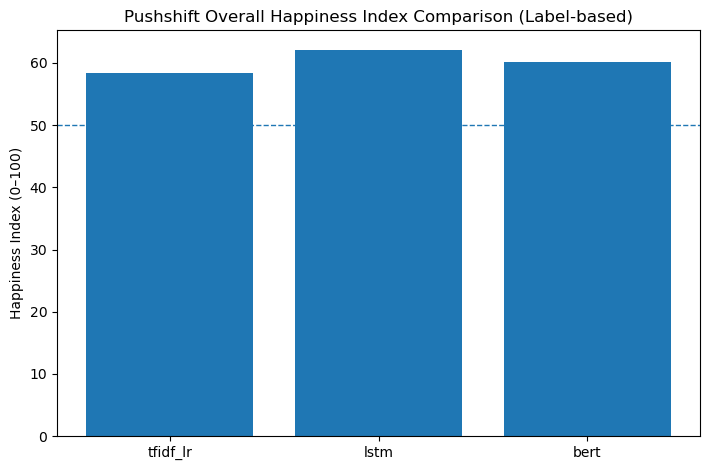

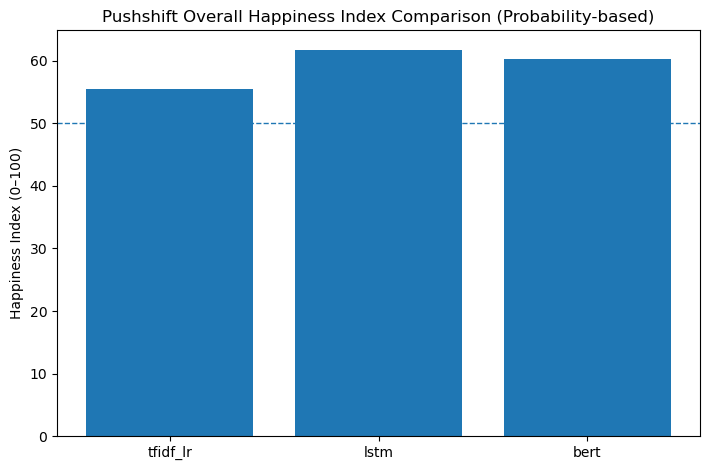

Pushshift class distribution by model:


,model,negative_ratio,neutral_ratio,positive_ratio
0,tfidf_lr,0.262225,0.309237,0.428538
1,lstm,0.254311,0.248878,0.496811
2,bert,0.284314,0.229861,0.485826


Highest label-based overall HI: {'model': 'lstm', 'hi_label_100': 62.124970470115755}
Highest probability-based overall HI: {'model': 'lstm', 'hi_prob_100': 61.77875372967652}

Saved files:
Combined summary: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/pushshift/pushshift_hi_summary_combined.csv
Compact comparison: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/pushshift/pushshift_hi_comparison_compact.csv
Overall table: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/pushshift/pushshift_hi_overall_table.csv
Class distribution: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/pushshift/pushshift_hi_class_distribution.csv
Best-summary table: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/pushshift/pushshift_hi_best_summary.csv
Label-based figure: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/pushshift/pushshift_hi_label_comparison.png
Probability-base

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Paths
# =========================
ROOT_DIR = Path.cwd()

if ROOT_DIR.name != "Code":
    for parent in [ROOT_DIR] + list(ROOT_DIR.parents):
        if parent.name == "Code":
            ROOT_DIR = parent
            break

if ROOT_DIR.name != "Code":
    raise ValueError(
        f"Could not locate the 'Code' directory from current working directory: {Path.cwd().resolve()}"
    )

ARTIFACT_DIR = ROOT_DIR / "artifacts"
PUSHSHIFT_DIR = ARTIFACT_DIR / "pushshift"
PUSHSHIFT_RESULT_DIR = PUSHSHIFT_DIR / "results"

FINAL_ANALYSIS_DIR = ARTIFACT_DIR / "final_analysis"
PUSHSHIFT_ANALYSIS_DIR = FINAL_ANALYSIS_DIR / "pushshift"
PUSHSHIFT_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print("Pushshift result directory:", PUSHSHIFT_RESULT_DIR.resolve())
print("Pushshift final analysis directory:", PUSHSHIFT_ANALYSIS_DIR.resolve())

# =========================
# Load summary files
# =========================
summary_files = {
    "tfidf_lr": PUSHSHIFT_RESULT_DIR / "tfidf_lr_happiness_index_summary.csv",
    "lstm": PUSHSHIFT_RESULT_DIR / "lstm_happiness_index_summary.csv",
    "bert": PUSHSHIFT_RESULT_DIR / "bert_happiness_index_summary.csv",
}

summary_dfs = []

for model_name, file_path in summary_files.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Missing summary file: {file_path}")

    df = pd.read_csv(file_path)
    df["model"] = model_name
    summary_dfs.append(df)

push_hi_df = pd.concat(summary_dfs, ignore_index=True)

print("Combined Pushshift HI summary:")
display(push_hi_df)

# =========================
# Basic cleaning / ordering
# =========================
model_order = ["tfidf_lr", "lstm", "bert"]

if "index_variant" in push_hi_df.columns:
    push_hi_df["index_variant"] = push_hi_df["index_variant"].astype(str).str.strip().str.lower()
else:
    push_hi_df["index_variant"] = "overall_temporal_ready"

push_hi_df["model"] = push_hi_df["model"].astype(str).str.strip().str.lower()
push_hi_df["model"] = push_hi_df["model"].replace({
    "tfidf_lr": "tfidf_lr",
    "glove_bilstm": "lstm",
    "lstm": "lstm",
    "bert_base": "bert",
    "bert-base-uncased": "bert",
    "bert": "bert",
})

push_hi_df["model"] = pd.Categorical(
    push_hi_df["model"],
    categories=model_order,
    ordered=True
)

push_hi_df = push_hi_df.sort_values(["model"]).reset_index(drop=True)

print("Cleaned and ordered Pushshift HI summary:")
display(push_hi_df)

combined_summary_path = PUSHSHIFT_ANALYSIS_DIR / "pushshift_hi_summary_combined.csv"
push_hi_df.to_csv(combined_summary_path, index=False, encoding="utf-8")

# =========================
# Compact comparison table
# =========================
comparison_cols = [
    "dataset",
    "model",
    "index_variant",
    "sample_size",
    "time_span_days",
    "temporal_window",
    "n_time_windows",
    "negative_ratio",
    "neutral_ratio",
    "positive_ratio",
    "mean_prob_negative",
    "mean_prob_neutral",
    "mean_prob_positive",
    "hi_label_raw",
    "hi_label_100",
    "hi_prob_raw",
    "hi_prob_100",
]

available_cols = [c for c in comparison_cols if c in push_hi_df.columns]
push_hi_compact = push_hi_df[available_cols].copy()

print("Compact Pushshift HI comparison table:")
display(push_hi_compact)

compact_path = PUSHSHIFT_ANALYSIS_DIR / "pushshift_hi_comparison_compact.csv"
push_hi_compact.to_csv(compact_path, index=False, encoding="utf-8")

# =========================
# Quick overall comparison table
# =========================
overall_table_cols = [
    "model",
    "sample_size",
    "temporal_window",
    "n_time_windows",
    "hi_label_100",
    "hi_prob_100",
    "negative_ratio",
    "neutral_ratio",
    "positive_ratio",
]
overall_table_cols = [c for c in overall_table_cols if c in push_hi_df.columns]

push_hi_overall_table = push_hi_df[overall_table_cols].copy()

print("Pushshift overall HI comparison table:")
display(push_hi_overall_table)

overall_table_path = PUSHSHIFT_ANALYSIS_DIR / "pushshift_hi_overall_table.csv"
push_hi_overall_table.to_csv(overall_table_path, index=False, encoding="utf-8")

# =========================
# Plot 1: hi_label_100 comparison
# =========================
plot_df_label = push_hi_df.copy()

plt.figure(figsize=(7.2, 4.8))
plt.bar(plot_df_label["model"].astype(str), plot_df_label["hi_label_100"])
plt.axhline(50, linestyle="--", linewidth=1)
plt.ylabel("Happiness Index (0–100)")
plt.title("Pushshift Overall Happiness Index Comparison (Label-based)")
plt.tight_layout()

label_fig_path = PUSHSHIFT_ANALYSIS_DIR / "pushshift_hi_label_comparison.png"
plt.savefig(label_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# =========================
# Plot 2: hi_prob_100 comparison
# =========================
plot_df_prob = push_hi_df.copy()

plt.figure(figsize=(7.2, 4.8))
plt.bar(plot_df_prob["model"].astype(str), plot_df_prob["hi_prob_100"])
plt.axhline(50, linestyle="--", linewidth=1)
plt.ylabel("Happiness Index (0–100)")
plt.title("Pushshift Overall Happiness Index Comparison (Probability-based)")
plt.tight_layout()

prob_fig_path = PUSHSHIFT_ANALYSIS_DIR / "pushshift_hi_prob_comparison.png"
plt.savefig(prob_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# =========================
# Class distribution comparison
# =========================
ratio_cols = ["negative_ratio", "neutral_ratio", "positive_ratio"]
ratio_available = [c for c in ratio_cols if c in push_hi_df.columns]

class_distribution_df = push_hi_df[["model"] + ratio_available].copy()

print("Pushshift class distribution by model:")
display(class_distribution_df)

class_distribution_path = PUSHSHIFT_ANALYSIS_DIR / "pushshift_hi_class_distribution.csv"
class_distribution_df.to_csv(class_distribution_path, index=False, encoding="utf-8")

# =========================
# Highest HI summary helper
# =========================
best_label_row = push_hi_df.loc[
    push_hi_df["hi_label_100"].idxmax(),
    ["model", "hi_label_100"]
]
best_prob_row = push_hi_df.loc[
    push_hi_df["hi_prob_100"].idxmax(),
    ["model", "hi_prob_100"]
]

best_summary_df = pd.DataFrame([
    {
        "summary_type": "highest_label_based_hi",
        "model": best_label_row["model"],
        "value": best_label_row["hi_label_100"],
    },
    {
        "summary_type": "highest_probability_based_hi",
        "model": best_prob_row["model"],
        "value": best_prob_row["hi_prob_100"],
    },
])

print("Highest label-based overall HI:", best_label_row.to_dict())
print("Highest probability-based overall HI:", best_prob_row.to_dict())

best_summary_path = PUSHSHIFT_ANALYSIS_DIR / "pushshift_hi_best_summary.csv"
best_summary_df.to_csv(best_summary_path, index=False, encoding="utf-8")

# =========================
# Save summary messages
# =========================
print("\nSaved files:")
print("Combined summary:", combined_summary_path.resolve())
print("Compact comparison:", compact_path.resolve())
print("Overall table:", overall_table_path.resolve())
print("Class distribution:", class_distribution_path.resolve())
print("Best-summary table:", best_summary_path.resolve())
print("Label-based figure:", label_fig_path.resolve())
print("Probability-based figure:", prob_fig_path.resolve())

## 4. Pushshift Temporal Happiness Index Comparison

This section compares the temporal happiness index trajectories of the three Pushshift models:
TF-IDF + Logistic Regression, GloVe + BiLSTM, and BERT.

Since all three temporal result files share the same schema, they can be merged into a unified long-format table for direct comparison across time windows.

The main comparison focuses on:
- the label-based temporal happiness index (`hi_label_100`)
- the probability-based temporal happiness index (`hi_prob_100`)

This section helps assess whether the three models produce consistent time-varying happiness signals on the Pushshift dataset.

Pushshift result directory: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/pushshift/results
Pushshift final analysis directory: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/pushshift
Combined Pushshift temporal HI table:


,time_window,time_window_start,time_window_start_utc,sample_size,negative_ratio,neutral_ratio,positive_ratio,mean_prob_negative,mean_prob_neutral,mean_prob_positive,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100,model
0,2022-01,2022-01-01,2022-01-01T00:00:00Z,692,0.238439,0.257225,0.504335,0.276973,0.253206,0.469821,0.265896,63.294798,0.192849,59.642428,tfidf_lr
1,2022-02,2022-02-01,2022-02-01T00:00:00Z,699,0.253219,0.284692,0.462089,0.300894,0.270591,0.428516,0.208870,60.443491,0.127622,56.381100,tfidf_lr
2,2022-03,2022-03-01,2022-03-01T00:00:00Z,735,0.278912,0.321088,0.400000,0.315454,0.281881,0.402665,0.121088,56.054422,0.087211,54.360533,tfidf_lr
3,2022-04,2022-04-01,2022-04-01T00:00:00Z,684,0.261696,0.321637,0.416667,0.306673,0.283536,0.409791,0.154971,57.748538,0.103118,55.155919,tfidf_lr
4,2022-05,2022-05-01,2022-05-01T00:00:00Z,695,0.269065,0.336691,0.394245,0.302486,0.303387,0.394127,0.125180,56.258993,0.091640,54.582011,tfidf_lr


Cleaned and ordered Pushshift temporal HI table:


,time_window,time_window_start,time_window_start_utc,sample_size,negative_ratio,neutral_ratio,positive_ratio,mean_prob_negative,mean_prob_neutral,mean_prob_positive,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100,model
0,2022-01,2022-01-01,2022-01-01T00:00:00Z,692,0.238439,0.257225,0.504335,0.276973,0.253206,0.469821,0.265896,63.294798,0.192849,59.642428,tfidf_lr
1,2022-01,2022-01-01,2022-01-01T00:00:00Z,692,0.251445,0.218208,0.530347,0.239960,0.239906,0.520134,0.278902,63.945087,0.280174,64.008678,lstm
2,2022-01,2022-01-01,2022-01-01T00:00:00Z,692,0.278902,0.202312,0.518786,0.275047,0.203365,0.521588,0.239884,61.994220,0.246542,62.327085,bert
3,2022-02,2022-02-01,2022-02-01T00:00:00Z,699,0.253219,0.284692,0.462089,0.300894,0.270591,0.428516,0.208870,60.443491,0.127622,56.381100,tfidf_lr
4,2022-02,2022-02-01,2022-02-01T00:00:00Z,699,0.257511,0.220315,0.522175,0.246911,0.245113,0.507977,0.264664,63.233190,0.261066,63.053317,lstm
5,2022-02,2022-02-01,2022-02-01T00:00:00Z,699,0.280401,0.190272,0.529328,0.274852,0.198090,0.527058,0.248927,62.446352,0.252207,62.610326,bert
6,2022-03,2022-03-01,2022-03-01T00:00:00Z,735,0.278912,0.321088,0.400000,0.315454,0.281881,0.402665,0.121088,56.054422,0.087211,54.360533,tfidf_lr
7,2022-03,2022-03-01,2022-03-01T00:00:00Z,735,0.257143,0.247619,0.495238,0.255573,0.270634,0.473793,0.238095,61.904762,0.218220,60.911020,lstm
8,2022-03,2022-03-01,2022-03-01T00:00:00Z,735,0.300680,0.234014,0.465306,0.297845,0.236452,0.465703,0.164626,58.231293,0.167857,58.392859,bert
9,2022-04,2022-04-01,2022-04-01T00:00:00Z,684,0.261696,0.321637,0.416667,0.306673,0.283536,0.409791,0.154971,57.748538,0.103118,55.155919,tfidf_lr


Compact Pushshift temporal HI table:


,time_window,time_window_start,time_window_start_utc,model,sample_size,negative_ratio,neutral_ratio,positive_ratio,mean_prob_negative,mean_prob_neutral,mean_prob_positive,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100
0,2022-01,2022-01-01,2022-01-01T00:00:00Z,tfidf_lr,692,0.238439,0.257225,0.504335,0.276973,0.253206,0.469821,0.265896,63.294798,0.192849,59.642428
1,2022-01,2022-01-01,2022-01-01T00:00:00Z,lstm,692,0.251445,0.218208,0.530347,0.239960,0.239906,0.520134,0.278902,63.945087,0.280174,64.008678
2,2022-01,2022-01-01,2022-01-01T00:00:00Z,bert,692,0.278902,0.202312,0.518786,0.275047,0.203365,0.521588,0.239884,61.994220,0.246542,62.327085
3,2022-02,2022-02-01,2022-02-01T00:00:00Z,tfidf_lr,699,0.253219,0.284692,0.462089,0.300894,0.270591,0.428516,0.208870,60.443491,0.127622,56.381100
4,2022-02,2022-02-01,2022-02-01T00:00:00Z,lstm,699,0.257511,0.220315,0.522175,0.246911,0.245113,0.507977,0.264664,63.233190,0.261066,63.053317
5,2022-02,2022-02-01,2022-02-01T00:00:00Z,bert,699,0.280401,0.190272,0.529328,0.274852,0.198090,0.527058,0.248927,62.446352,0.252207,62.610326
6,2022-03,2022-03-01,2022-03-01T00:00:00Z,tfidf_lr,735,0.278912,0.321088,0.400000,0.315454,0.281881,0.402665,0.121088,56.054422,0.087211,54.360533
7,2022-03,2022-03-01,2022-03-01T00:00:00Z,lstm,735,0.257143,0.247619,0.495238,0.255573,0.270634,0.473793,0.238095,61.904762,0.218220,60.911020
8,2022-03,2022-03-01,2022-03-01T00:00:00Z,bert,735,0.300680,0.234014,0.465306,0.297845,0.236452,0.465703,0.164626,58.231293,0.167857,58.392859
9,2022-04,2022-04-01,2022-04-01T00:00:00Z,tfidf_lr,684,0.261696,0.321637,0.416667,0.306673,0.283536,0.409791,0.154971,57.748538,0.103118,55.155919


Temporal hi_label_100 pivot:


model,tfidf_lr,lstm,bert
time_window_start,,,
2022-01-01,63.294798,63.945087,61.994220
2022-02-01,60.443491,63.233190,62.446352
2022-03-01,56.054422,61.904762,58.231293
2022-04-01,57.748538,60.526316,59.722222
2022-05-01,56.258993,59.136691,56.978417
2022-06-01,59.686610,61.111111,58.190883
2022-07-01,56.762295,61.475410,60.177596
2022-08-01,57.613470,63.323572,60.761347
2022-09-01,56.406869,61.096433,57.859974


Temporal hi_prob_100 pivot:


model,tfidf_lr,lstm,bert
time_window_start,,,
2022-01-01,59.642428,64.008678,62.327085
2022-02-01,56.381100,63.053317,62.610326
2022-03-01,54.360533,60.911020,58.392859
2022-04-01,55.155919,60.553762,59.910879
2022-05-01,54.582011,58.901190,57.481156
2022-06-01,55.451957,61.269131,58.507938
2022-07-01,54.336661,61.031311,60.171504
2022-08-01,55.719802,63.101401,61.197748
2022-09-01,54.330693,60.768134,57.858798


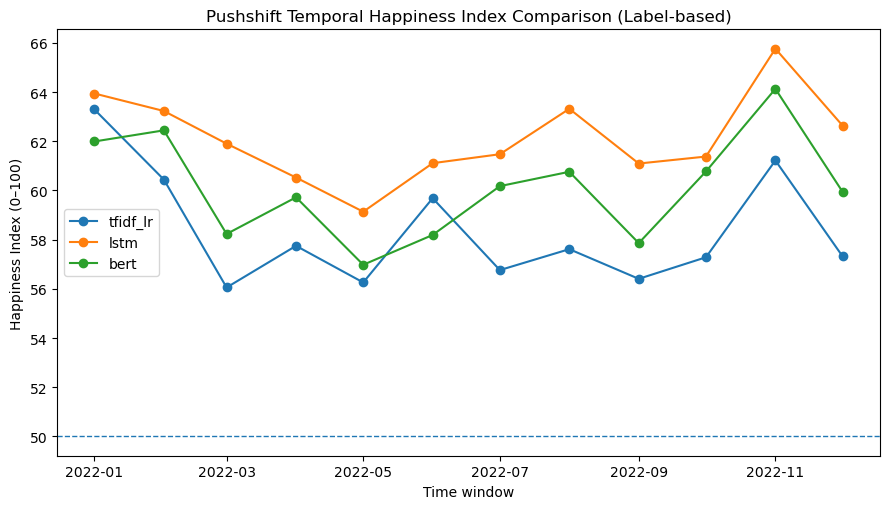

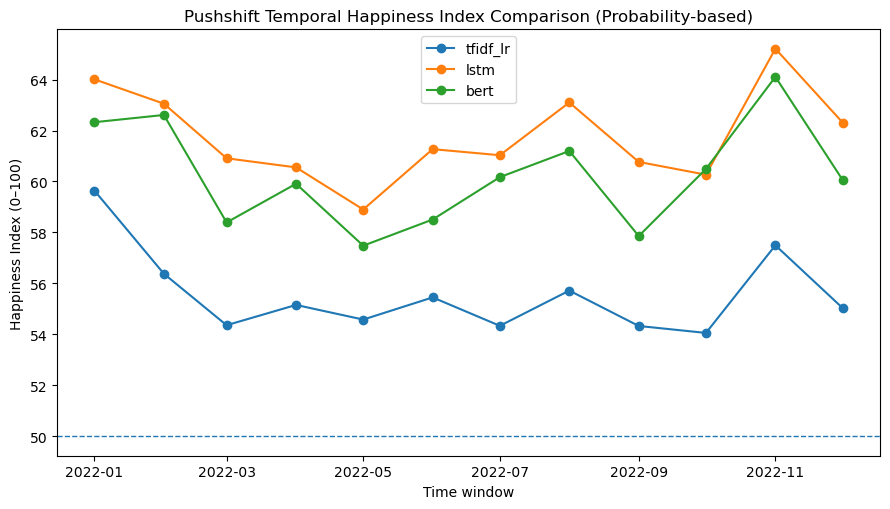

Pushshift temporal summary by model:


,model,n_windows,min_window,max_window,mean_hi_label_100,mean_hi_prob_100,std_hi_label_100,std_hi_prob_100
0,tfidf_lr,12,2022-01-01,2022-12-01,58.341273,55.545955,2.294361,1.629849
1,lstm,12,2022-01-01,2022-12-01,62.128218,61.782558,1.760706,1.785519
2,bert,12,2022-01-01,2022-12-01,60.101206,60.260069,2.096011,2.038970


Temporal rank comparison preview:


,time_window,time_window_start,model,hi_label_100,hi_prob_100,label_rank_within_window,prob_rank_within_window
0,2022-01,2022-01-01,tfidf_lr,63.294798,59.642428,2.0,3.0
1,2022-01,2022-01-01,lstm,63.945087,64.008678,1.0,1.0
2,2022-01,2022-01-01,bert,61.994220,62.327085,3.0,2.0
3,2022-02,2022-02-01,tfidf_lr,60.443491,56.381100,3.0,3.0
4,2022-02,2022-02-01,lstm,63.233190,63.053317,1.0,1.0
5,2022-02,2022-02-01,bert,62.446352,62.610326,2.0,2.0
6,2022-03,2022-03-01,tfidf_lr,56.054422,54.360533,3.0,3.0
7,2022-03,2022-03-01,lstm,61.904762,60.911020,1.0,1.0
8,2022-03,2022-03-01,bert,58.231293,58.392859,2.0,2.0
9,2022-04,2022-04-01,tfidf_lr,57.748538,55.155919,3.0,3.0



Saved files:
Combined temporal summary: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/pushshift/pushshift_temporal_hi_combined.csv
Compact temporal table: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/pushshift/pushshift_temporal_hi_compact.csv
Label temporal pivot: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/pushshift/pushshift_temporal_hi_label_pivot.csv
Probability temporal pivot: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/pushshift/pushshift_temporal_hi_prob_pivot.csv
Window summary: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/pushshift/pushshift_temporal_hi_window_summary.csv
Rank comparison: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/pushshift/pushshift_temporal_hi_rank_comparison.csv
Label-based temporal figure: /Users/victor/Desktop/Graduation_Thesis/Code/artifacts/final_analysis/pushshift/pushshift_temporal_hi_label_comparis

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Paths
# =========================
ROOT_DIR = Path.cwd()

if ROOT_DIR.name != "Code":
    for parent in [ROOT_DIR] + list(ROOT_DIR.parents):
        if parent.name == "Code":
            ROOT_DIR = parent
            break

if ROOT_DIR.name != "Code":
    raise ValueError(
        f"Could not locate the 'Code' directory from current working directory: {Path.cwd().resolve()}"
    )

ARTIFACT_DIR = ROOT_DIR / "artifacts"
PUSHSHIFT_DIR = ARTIFACT_DIR / "pushshift"
PUSHSHIFT_RESULT_DIR = PUSHSHIFT_DIR / "results"

FINAL_ANALYSIS_DIR = ARTIFACT_DIR / "final_analysis"
PUSHSHIFT_ANALYSIS_DIR = FINAL_ANALYSIS_DIR / "pushshift"
PUSHSHIFT_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print("Pushshift result directory:", PUSHSHIFT_RESULT_DIR.resolve())
print("Pushshift final analysis directory:", PUSHSHIFT_ANALYSIS_DIR.resolve())

# =========================
# Load temporal files
# =========================
temporal_files = {
    "tfidf_lr": PUSHSHIFT_RESULT_DIR / "tfidf_lr_temporal_happiness_index.csv",
    "lstm": PUSHSHIFT_RESULT_DIR / "lstm_temporal_happiness_index.csv",
    "bert": PUSHSHIFT_RESULT_DIR / "bert_temporal_happiness_index.csv",
}

temporal_dfs = []

for model_name, file_path in temporal_files.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Missing temporal HI file: {file_path}")

    df = pd.read_csv(file_path)
    df["model"] = model_name
    temporal_dfs.append(df)

push_temporal_df = pd.concat(temporal_dfs, ignore_index=True)

print("Combined Pushshift temporal HI table:")
display(push_temporal_df.head())

# =========================
# Basic cleaning / ordering
# =========================
model_order = ["tfidf_lr", "lstm", "bert"]

push_temporal_df["model"] = push_temporal_df["model"].astype(str).str.strip().str.lower()
push_temporal_df["model"] = push_temporal_df["model"].replace({
    "tfidf_lr": "tfidf_lr",
    "glove_bilstm": "lstm",
    "lstm": "lstm",
    "bert_base": "bert",
    "bert-base-uncased": "bert",
    "bert": "bert",
})

push_temporal_df["model"] = pd.Categorical(
    push_temporal_df["model"],
    categories=model_order,
    ordered=True
)

# Parse time for plotting
push_temporal_df["time_window_start"] = pd.to_datetime(
    push_temporal_df["time_window_start"],
    errors="coerce"
)

push_temporal_df = push_temporal_df.sort_values(
    ["time_window_start", "model"]
).reset_index(drop=True)

print("Cleaned and ordered Pushshift temporal HI table:")
display(push_temporal_df.head(10))

combined_temporal_path = PUSHSHIFT_ANALYSIS_DIR / "pushshift_temporal_hi_combined.csv"
push_temporal_df.to_csv(combined_temporal_path, index=False, encoding="utf-8")

# =========================
# Compact comparison table
# =========================
comparison_cols = [
    "time_window",
    "time_window_start",
    "time_window_start_utc",
    "model",
    "sample_size",
    "negative_ratio",
    "neutral_ratio",
    "positive_ratio",
    "mean_prob_negative",
    "mean_prob_neutral",
    "mean_prob_positive",
    "hi_label_raw",
    "hi_label_100",
    "hi_prob_raw",
    "hi_prob_100",
]

available_cols = [c for c in comparison_cols if c in push_temporal_df.columns]
push_temporal_compact = push_temporal_df[available_cols].copy()

print("Compact Pushshift temporal HI table:")
display(push_temporal_compact.head(12))

compact_temporal_path = PUSHSHIFT_ANALYSIS_DIR / "pushshift_temporal_hi_compact.csv"
push_temporal_compact.to_csv(compact_temporal_path, index=False, encoding="utf-8")

# =========================
# Pivot tables for direct comparison
# =========================
label_temporal_pivot = push_temporal_df.pivot(
    index="time_window_start",
    columns="model",
    values="hi_label_100"
)

prob_temporal_pivot = push_temporal_df.pivot(
    index="time_window_start",
    columns="model",
    values="hi_prob_100"
)

print("Temporal hi_label_100 pivot:")
display(label_temporal_pivot)

print("Temporal hi_prob_100 pivot:")
display(prob_temporal_pivot)

label_temporal_pivot_path = PUSHSHIFT_ANALYSIS_DIR / "pushshift_temporal_hi_label_pivot.csv"
prob_temporal_pivot_path = PUSHSHIFT_ANALYSIS_DIR / "pushshift_temporal_hi_prob_pivot.csv"

label_temporal_pivot.to_csv(label_temporal_pivot_path, encoding="utf-8")
prob_temporal_pivot.to_csv(prob_temporal_pivot_path, encoding="utf-8")

# =========================
# Plot 1: label-based temporal HI
# =========================
plt.figure(figsize=(9, 5.2))

for model_name in model_order:
    sub = push_temporal_df[push_temporal_df["model"] == model_name]
    plt.plot(
        sub["time_window_start"],
        sub["hi_label_100"],
        marker="o",
        label=model_name
    )

plt.axhline(50, linestyle="--", linewidth=1)
plt.xlabel("Time window")
plt.ylabel("Happiness Index (0–100)")
plt.title("Pushshift Temporal Happiness Index Comparison (Label-based)")
plt.legend()
plt.tight_layout()

label_temporal_fig_path = PUSHSHIFT_ANALYSIS_DIR / "pushshift_temporal_hi_label_comparison.png"
plt.savefig(label_temporal_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# =========================
# Plot 2: probability-based temporal HI
# =========================
plt.figure(figsize=(9, 5.2))

for model_name in model_order:
    sub = push_temporal_df[push_temporal_df["model"] == model_name]
    plt.plot(
        sub["time_window_start"],
        sub["hi_prob_100"],
        marker="o",
        label=model_name
    )

plt.axhline(50, linestyle="--", linewidth=1)
plt.xlabel("Time window")
plt.ylabel("Happiness Index (0–100)")
plt.title("Pushshift Temporal Happiness Index Comparison (Probability-based)")
plt.legend()
plt.tight_layout()

prob_temporal_fig_path = PUSHSHIFT_ANALYSIS_DIR / "pushshift_temporal_hi_prob_comparison.png"
plt.savefig(prob_temporal_fig_path, dpi=300, bbox_inches="tight")
plt.show()

# =========================
# Temporal range / window summary
# =========================
window_summary = (
    push_temporal_df.groupby("model", observed=True)
    .agg(
        n_windows=("time_window", "nunique"),
        min_window=("time_window_start", "min"),
        max_window=("time_window_start", "max"),
        mean_hi_label_100=("hi_label_100", "mean"),
        mean_hi_prob_100=("hi_prob_100", "mean"),
        std_hi_label_100=("hi_label_100", "std"),
        std_hi_prob_100=("hi_prob_100", "std"),
    )
    .reset_index()
)

print("Pushshift temporal summary by model:")
display(window_summary)

window_summary_path = PUSHSHIFT_ANALYSIS_DIR / "pushshift_temporal_hi_window_summary.csv"
window_summary.to_csv(window_summary_path, index=False, encoding="utf-8")

# =========================
# Optional: month-by-month rank comparison
# =========================
rank_df = push_temporal_df.copy()
rank_df["label_rank_within_window"] = rank_df.groupby("time_window_start")["hi_label_100"].rank(
    ascending=False,
    method="dense"
)
rank_df["prob_rank_within_window"] = rank_df.groupby("time_window_start")["hi_prob_100"].rank(
    ascending=False,
    method="dense"
)

print("Temporal rank comparison preview:")
display(rank_df[[
    "time_window",
    "time_window_start",
    "model",
    "hi_label_100",
    "hi_prob_100",
    "label_rank_within_window",
    "prob_rank_within_window"
]].head(12))

rank_path = PUSHSHIFT_ANALYSIS_DIR / "pushshift_temporal_hi_rank_comparison.csv"
rank_df.to_csv(rank_path, index=False, encoding="utf-8")

# =========================
# Save summary messages
# =========================
print("\nSaved files:")
print("Combined temporal summary:", combined_temporal_path.resolve())
print("Compact temporal table:", compact_temporal_path.resolve())
print("Label temporal pivot:", label_temporal_pivot_path.resolve())
print("Probability temporal pivot:", prob_temporal_pivot_path.resolve())
print("Window summary:", window_summary_path.resolve())
print("Rank comparison:", rank_path.resolve())
print("Label-based temporal figure:", label_temporal_fig_path.resolve())
print("Probability-based temporal figure:", prob_temporal_fig_path.resolve())